In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Look at the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Convert TotalCharges to numeric, turning errors (spaces) into NaN (empty)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many empty rows we created
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Since it's only 11 rows out of 7000, we can safely drop them
df.dropna(inplace=True)

# Drop CustomerID - it's useless for prediction
df.drop('customerID', axis=1, inplace=True)

Missing values in TotalCharges: 11


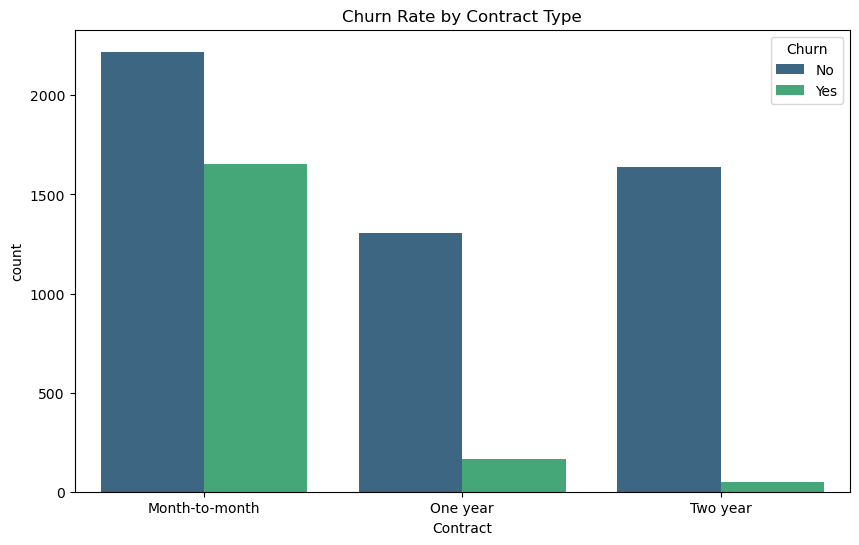

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.show()

In [5]:
# Create a list of columns that have 'Yes' and 'No'
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Gender is also binary, but different labels
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

In [6]:
# Convert multi-category columns into separate 1/0 columns
df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 'OnlineSecurity', 
                                'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                                'StreamingTV', 'StreamingMovies', 'Contract', 
                                'PaymentMethod'])

# Let's see the new shape of our data
print(f"New dataset shape: {df.shape}")
df.head()

New dataset shape: (7032, 41)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


In [7]:
from sklearn.model_selection import train_test_split

# X = Features (everything except the answer), y = Target (the answer)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")

Data successfully split!


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the model with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model (The "Learning" phase)
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set (The "Exam" phase)
y_pred = rf_model.predict(X_test)

print("Model training complete!")

Model training complete!


Accuracy Score: 78.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



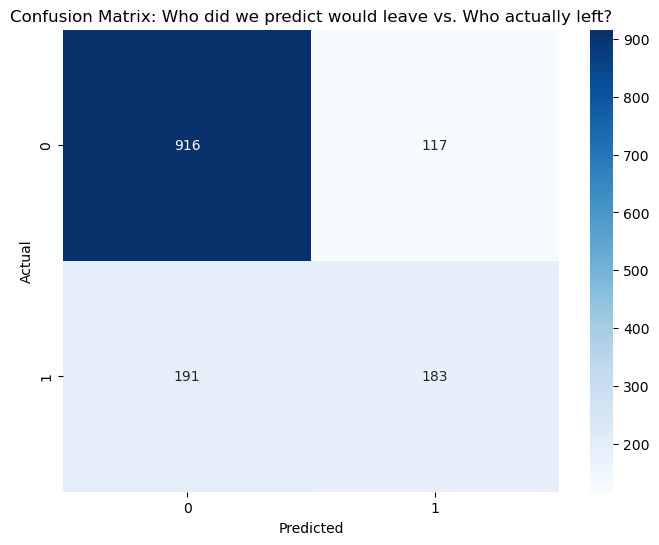

In [9]:
# Print the accuracy
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")

# Print a detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot a Confusion Matrix (The 'Gold Standard' for HR presentations)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Who did we predict would leave vs. Who actually left?')
plt.show()

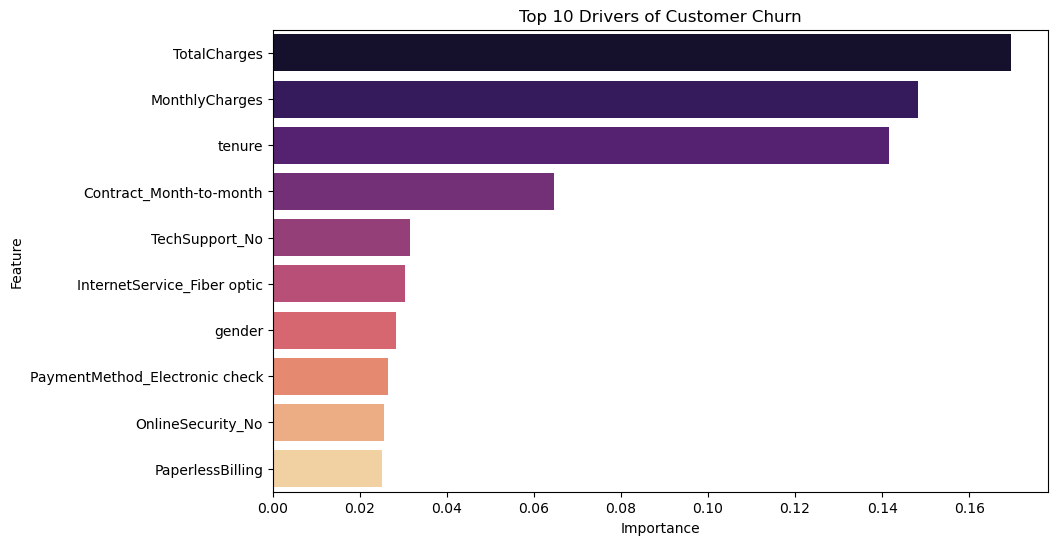

In [10]:
# Get feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort and plot the top 10
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='magma')
plt.title('Top 10 Drivers of Customer Churn')
plt.show()
